In [1]:
TRUE_LABEL = 'Final_Label'

models = {
    "BERT": "arabert_baseline_pred",

    "ALLAM zero shot": "allam_zero_pred",
    "ALLAM one shot": "allam_one_pred",
    "ALLAM few shot": "allam_few_pred",
    "Lora ALLAM": "lora_allam_pred",

    "LLaMA zero shot": "llama_zero_pred",
    "LLaMA one shot": "llama_one_pred",
    "LLaMA few shot": "llama_few_pred",
}

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Final_Results.csv")

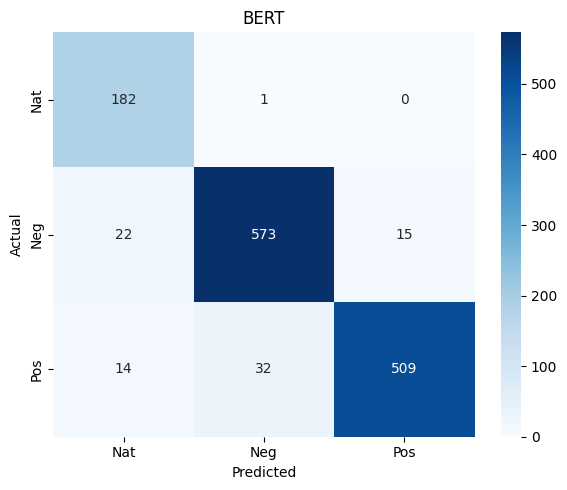

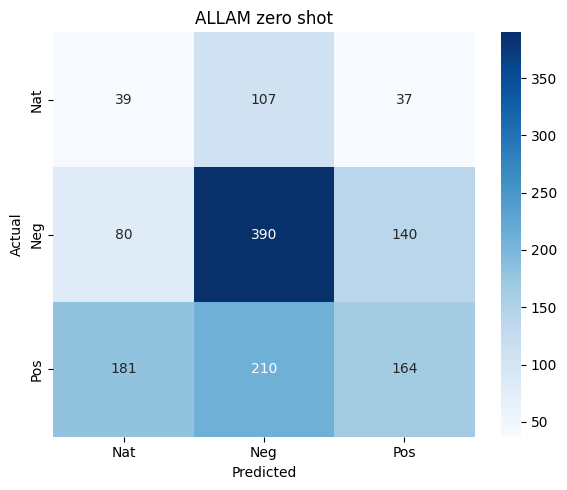

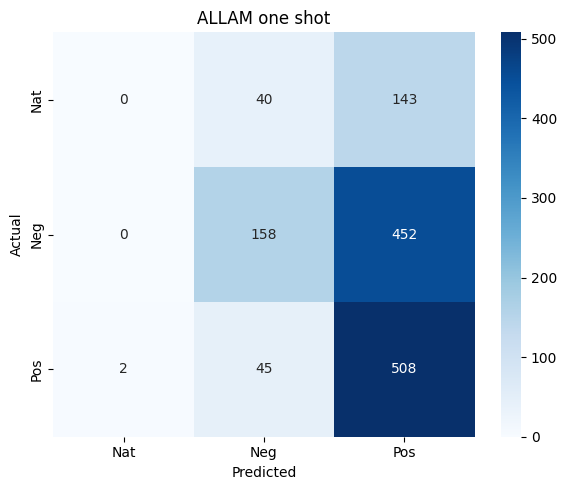

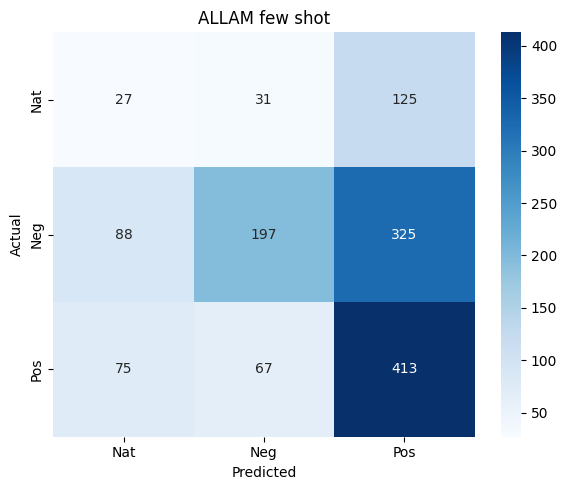

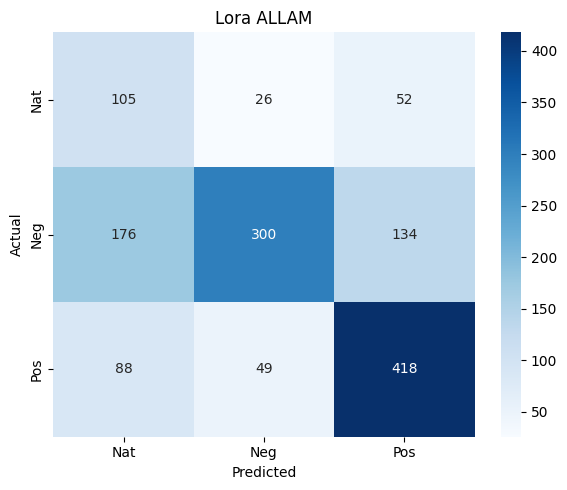

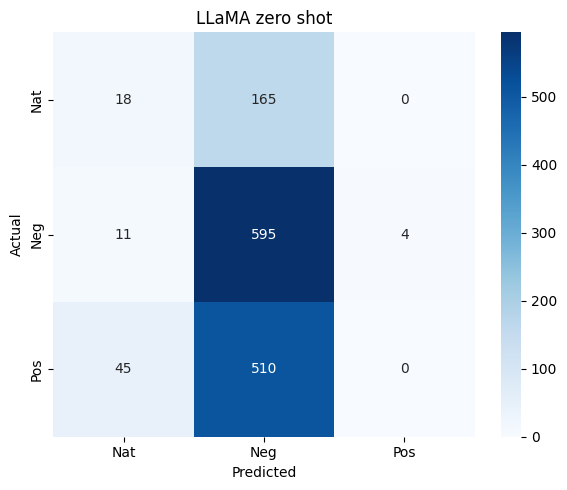

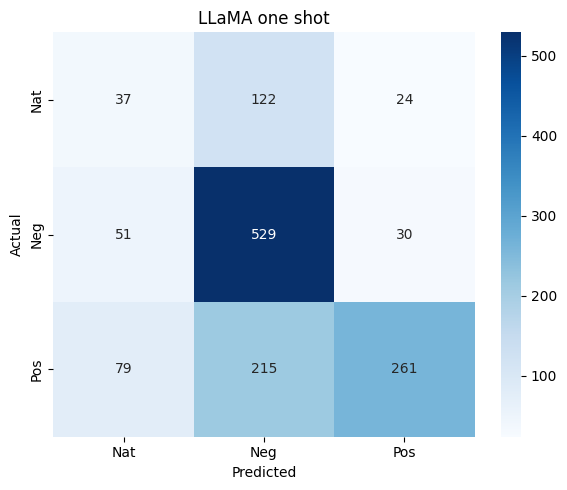

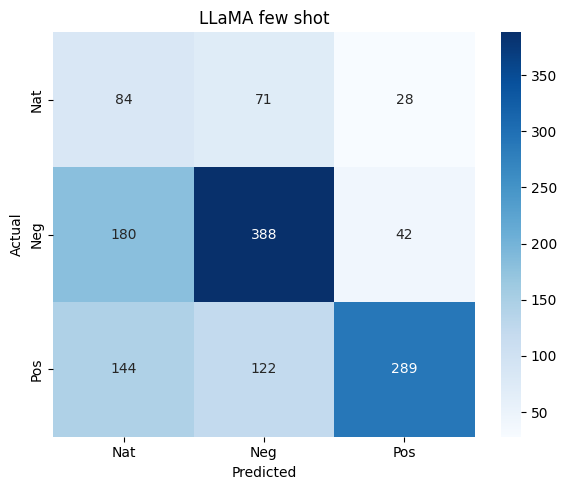

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get unique labels from the true labels, and sort them for consistent plotting
unique_labels = sorted(df[TRUE_LABEL].unique())

for name, col in models.items():
    fig, ax = plt.subplots(figsize=(6, 5)) # Create a new figure and axis for each plot
    cm = confusion_matrix(df[TRUE_LABEL], df[col], labels=unique_labels)

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=unique_labels,
                yticklabels=unique_labels,
                ax=ax)

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show() # Display each plot immediately after creation

In [13]:
def error_type(true, pred):
    if true != pred:
        return "Wrong"
    else:
        return "Correct"

In [14]:
models = {
    "BERT": "arabert_baseline_pred",

    "ALLAM zero shot": "allam_zero_pred",
    "ALLAM one shot": "allam_one_pred",
    "ALLAM few shot": "allam_few_pred",
    "Lora ALLAM": "lora_allam_pred",

    "LLaMA zero shot": "llama_zero_pred",
    "LLaMA one shot": "llama_one_pred",
    "LLaMA few shot": "llama_few_pred",
}

errors_list = []

for name, col in models.items():

    temp = df.copy()
    temp['predicted'] = temp[col]
    temp['model'] = name

    temp['is_error'] = temp['Final_Label'] != temp['predicted']

    errors = temp[temp['is_error'] == True]

    errors_list.append(errors)

errors_df = pd.concat(errors_list, ignore_index=True)

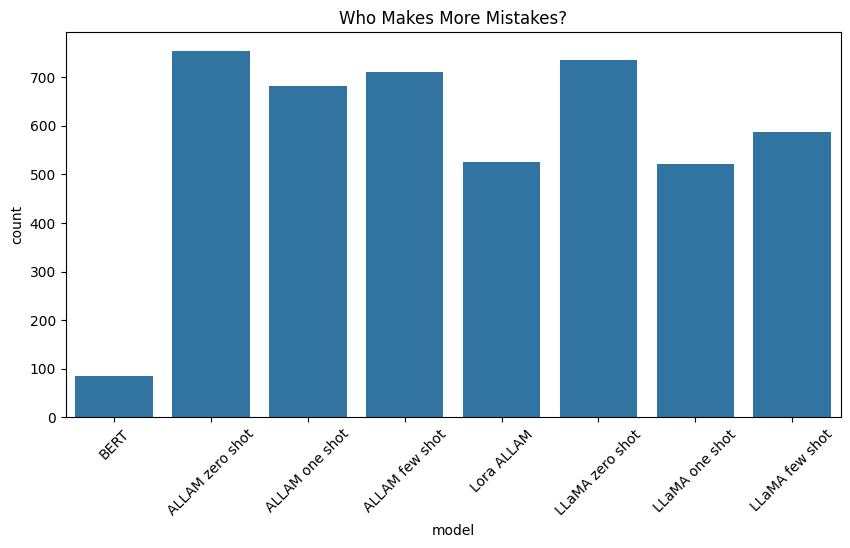

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(data=errors_df, x='model')

plt.title("Who Makes More Mistakes?")
plt.xticks(rotation=45)
plt.show()

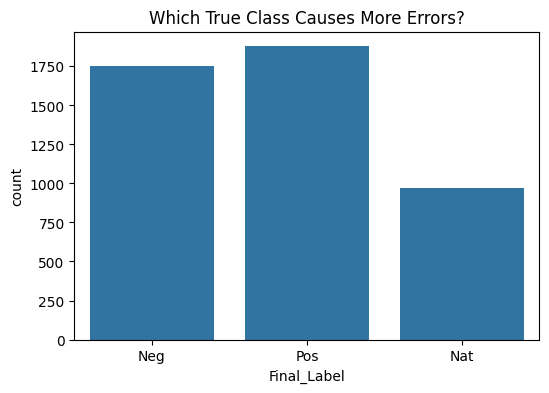

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=errors_df, x='Final_Label')

plt.title("Which True Class Causes More Errors?")
plt.show()

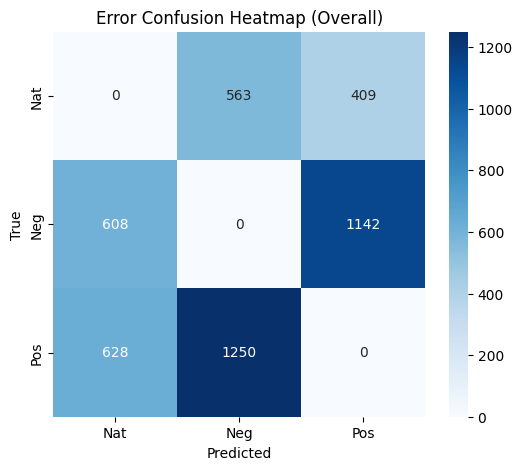

In [17]:
pivot = pd.crosstab(errors_df['Final_Label'], errors_df['predicted'])

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')

plt.title("Error Confusion Heatmap (Overall)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

the best model per each stance

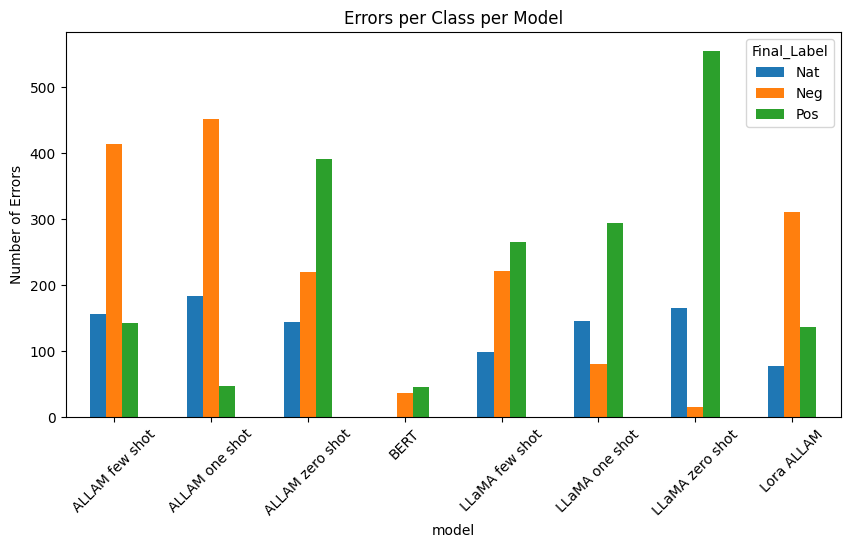

In [18]:
class_error = errors_df.groupby(['model', 'Final_Label']).size().unstack()

class_error.plot(kind='bar', figsize=(10,5))

plt.title("Errors per Class per Model")
plt.ylabel("Number of Errors")
plt.xticks(rotation=45)
plt.show()

#Sample Error

In [32]:
from warnings import filterwarnings
filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)

samples = (
    errors_df
    .groupby('model')
    .apply(lambda x: x.sample(n=min(10, len(x)), random_state=42))
    .reset_index(drop=True)
)

for model_name in samples['model'].unique():
    print(f"\n===== {model_name} =====")
    display(samples[samples['model'] == model_name][['text', 'Final_Label', 'predicted']])


===== ALLAM few shot =====


,text,Final_Label,predicted
0,😂😂😂,Neg,Pos
1,الى اين ستصل السعودية مع ابن سلمان؟!,Neg,Pos
2,الطموح واضح وكبير، لكن التنفيذ حتى الآن ما زال غير واضح المعالم. سيدات النصر بحاجة إلى توازن أدق بين الدفاع والهجوم. 🤔,Nat,Neg
3,كانت محجبه وشالته والله حرام,Neg,Nat
4,هذا قدرك تنزل ملخص سيدات,Neg,Pos
5,الحساب يوم الحساب,Neg,Pos
6,لاعبات الأهلي السعوديات مربربات كيف الاداره ساكتين عنهم ؟,Neg,Pos
7,يعني بتلعب كرة قدم بالحجاب ؟!!\nهي تبرجت بلعبها من البداية,Neg,Pos
8,هل تذكر الرئيس كيسيه 💚💚🤍🤍,Nat,Pos
9,قد نساء النصر افضل من رجاله,Pos,Nat



===== ALLAM one shot =====


,text,Final_Label,predicted
10,انت اعتقدت ان تغريدة سيدات النصر إيحاء جنسي … لذلك رأيك ونظرتك خلها في محيط تربيتك,Pos,Neg
11,فرحانه بنفسك يعني ملاكمه الله يستر بس,Neg,Pos
12,أحس مجتمعنا له خصوصيته مو لازم نقلد أحد هذا المجال مايناسب بناتنا,Neg,Pos
13,الله يستر معاورنا,Neg,Pos
14,بلد التوحيد\nرجعت وبلد المسخره للاسلام والمسلمين \nلعنه الله بتحل عليكم يا ال سعود,Neg,Pos
15,ولا ننسى ان ندعي على حكام العرب المتخاذلين والمطبعين وحكام المسلمين الجبناء الخوانه العملاء اللهم يا الله يا قوي يا جبار اللهم أرنا فيهم عجائب قدرتك وقوتك وغضبك ونقمتك يارب العالمين,Neg,Pos
16,حتى لو غابت عدسات الكاميرات معكم بقلوبنا و إن لم نشاهدكم 💚 نثق بكم ونفخر بخطواتكم الأولى نحو التاريخ كل الدعوات و الأمنيات مع أخضرنا في مرحلة تاريخية و مهمة ، و كل التوفيق لنجمات منتخبنا الوطني لكتابة فصل جديد من المجد 🌟 |,Pos,Neg
17,لسع إلى الآن الاهلي تحت التدريب 👍🏼,Nat,Neg
18,قال الصح والكثير من الناس تقوله عادي جدا الموضوع مثل ماقال المرأه السعوديه تعليم صحه تربيه تثقف أجيال تعمل في اي مجال نسائي الا الرياضه لا والف لا لا ديننا ولا تقاليدنا تسمح بذلك صادق المصيبيح عجزو يحققون الرجال شي في اولمبياد تبغى المراه تحقق شي اقول مثله دعو المراه في حالها,Neg,Pos
19,اتمنى من القائمين على مسابقات كرة القدم السعودية النسائية وضع تقنية الفار في المباريات التنافسية لاني رأيت في المواسم السابقة حالات تحكيمية جدلية غيرت نتائج .,Nat,Pos



===== ALLAM zero shot =====


...

,text,Final_Label,predicted
50,انت اعتقدت ان تغريدة سيدات النصر إيحاء جنسي … لذلك رأيك ونظرتك خلها في محيط تربيتك,Pos,Neg
51,الفترة الاخيرة صايره أتابع دوري السيدات، ما توقعته مُمتع، وفيه منافسة قوية الصراحة سيدات الهلال والنصر متعادلين بالنقاط، لكن لسوء حظ سيدات الهلال جدول سيدات النصر اسهل (طبعًا كلها صدفة) في حال سيدات الهلال حققوا الدوري بتكون أول بطولة لهم في تاريخهم، وبيشاركون بالنخبة,Pos,Nat
52,يمكن الجيل الجديد رح يقدر يتقبل موضوع مجال المرأة بالرياضة أكثر واسرع,Nat,Pos
53,احنا الستينات بالنسبة لنا ذا الوقت حضارة .... وضع حزين عالم مدروخة ومحدش شغال,Pos,Neg
54,الله يستر معاورنا,Neg,Nat
55,كلهم يلعبون احسن من هارون كمارا حقيقه لابد تنقال يعني,Pos,Neg
56,في الخش والدس ليش ما تنعرض مباريات بناتنا في الدوري السعودي النسائي في القنوات الرسميه؟,Nat,Neg
57,واضح إن فيه تعب وشغل كبير وراء اللي نشوفه. برافو بناتنا عساكم عالقوه,Nat,Neg
58,بالتوفيق يا بنات احبكم,Pos,Nat
59,الطموح واضح وكبير، لكن التنفيذ حتى الآن ما زال غير واضح المعالم. سيدات النصر بحاجة إلى توازن أدق بين الدفاع والهجوم. 🤔,Nat,Neg



===== LLaMA zero shot =====


,text,Final_Label,predicted
60,ضاع نص عمري وانا اشجع ميسي 😅😅,Pos,Neg
61,أشوف الصورة العامة كالتالي. اللاعبات السعوديات: النتائج متذبذبة شوي، بس المؤشرات إيجابية على المدى القريب. 🤝,Pos,Neg
62,وش سووا يا المتدين انت,Pos,Neg
63,هذي خي بروين مو دي بروين ههههههههههههههههههههههههههههههههههههههههههههههههههههههههههههههههههه ههههههههههههههههههههههههههههههههههههههههههههههههههههههههههههههههههه,Neg,Nat
64,😂😂😂البنات خير من اللعيبه الرجال,Pos,Neg
65,مجالات رياضيه متعدده خاضتها المرأة و نجاحات كبيرة حققتها,Pos,Neg
66,من نجاح لنجاح يابناتنا الله يوفقكم👍🏻💗,Pos,Nat
67,نبي نشوف بنات سعوديات في مجال الرياضه غير الكورة بليز,Nat,Neg
68,فيه نقاط قوة ونقاط ضعف بنفس الوقت بس شي طبيعي مجال جديد يحتاج وقت,Nat,Neg
69,ماشاءالله نص درزن اللهم زد وبارك عقبال كل شىء حلو لبناتنا الغاليات ومنتخبنا الله يعزكم يابنات سلمان الحزم وحظ أوفر لبنات الكويت,Pos,Neg



===== Lora ALLAM =====


,text,Final_Label,predicted
70,ليش الكذب لو كنتي ماسكه الايفنت بتجيبين هتان السيف فيه خيارات افضل والناس تبي واجهه صراحه لو على الانجازات ماحد طلع,Neg,Pos
71,سلم عليه وقوله بمستواك هذا لن تتنافس حتى على بطوله في دوري السيدات,Neg,Nat
72,الله يستر معاورنا,Neg,Nat
73,اليوم تأيد رياضة المرأه السعوديه والحين تغريد بحبك للوطن ولو تحب الوطن كان تأيد الستر والعفه للمرأه هو الحامي لها بعد الله,Neg,Pos
74,وين الحشمة يا بنات حسبي الله على من خرب نظام المملكه والله انا اغتربت فيها فترة ما كنت اشوف بنت غير محتشمه الان اشوفهن في مواقع التواصل ولا اصدق عيوني كيف صارت,Neg,Pos
75,الدوري للنصر,Nat,Pos
76,والله لو لاعبين مع حواري ماتجي النتيجه ذي,Neg,Pos
77,احتفل انت وباقي القطيع بالبطوله الاوروبيه لأن ناديكم المتهالك مايجمل تحتفل له علىٰ الأقل آخر بطولة بطولة دوري السيدات احتفلوا فيها😂😂😂,Neg,Pos
78,الحساب يوم الحساب,Neg,Pos
79,هي لاعبة عظيمة لكن ليش خلعت الحجاب ؟؟,Pos,Nat
